In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,Flowers102


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
])

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/butterfly'
model_algo="alexnet"

In [4]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImagecsvDataset(DATA_DIR+"/train",'/home/pcdm/Desktop/butterfly/Training_set.csv',transform)

size=len(images)

generator = torch.Generator()
generator.manual_seed(124)

valid_size = int(0.2 * size)
train_size = int(size - valid_size )

trainset, validset = random_split(images, (train_size, valid_size), generator=generator)


In [6]:
valid_size

1299

In [7]:
train_size

5200

In [8]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=False, batch_size=batch_size,num_workers=4)
valid_dl = DataLoader(validset,shuffle=False, batch_size=batch_size,num_workers=4)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.5397623024537013,train_accu=0.8521153846153846
Epoch=0,valid_loss=0.8153246035476756,valid_accu=0.7906081601231717
0
Epoch=1,train_loss=0.25615670311909455,train_accu=0.9255769230769231
Epoch=1,valid_loss=0.5971171756814864,valid_accu=0.8437259430331023
0
Epoch=2,train_loss=0.18419259717831246,train_accu=0.9409615384615385
Epoch=2,valid_loss=0.6596796491381937,valid_accu=0.8383371824480369
Epoch=3,train_loss=0.15160258618684916,train_accu=0.9517307692307693
Epoch=3,valid_loss=0.6785519343784353,valid_accu=0.8344880677444187
Epoch=4,train_loss=0.10860355186347778,train_accu=0.9671153846153846
Epoch=4,valid_loss=0.6968088902882927,valid_accu=0.8391070053887606
Epoch=5,train_loss=0.12264169040709161,train_accu=0.9611538461538461
Epoch=5,valid_loss=0.7615164573762488,valid_accu=0.836027713625866
4 Early stopping!


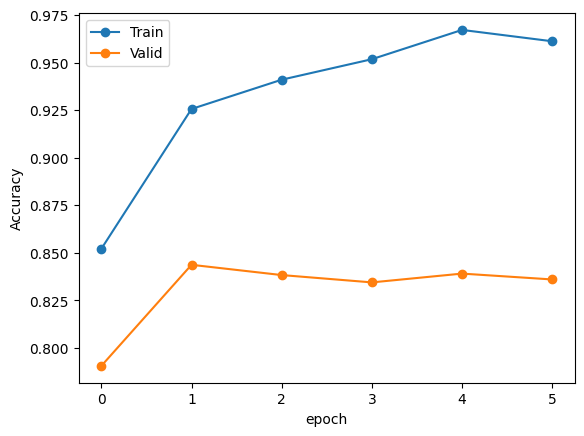

In [9]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_7.pth')

In [10]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.25409470732395467, 0.9263461538461538)

In [11]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.6084816798602186, 0.8367975365665897)

In [12]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [13]:
each_accu=p
each_accu

ADONIS                       0.985075
AFRICAN GIANT SWALLOWTAIL    0.982759
AMERICAN SNOOT               0.842105
AN 88                        1.000000
APPOLLO                      0.985075
                               ...   
ULYSES                       0.955882
VICEROY                      0.507692
WOOD SATYR                   0.983051
YELLOW SWALLOW TAIL          0.983871
ZEBRA LONG WING              1.000000
Length: 75, dtype: float64

In [14]:
each_f1=2*p*r/(p+r)
each_f1

ADONIS                       0.985075
AFRICAN GIANT SWALLOWTAIL    0.991304
AMERICAN SNOOT               0.914286
AN 88                        1.000000
APPOLLO                      0.963504
                               ...   
ULYSES                       0.977444
VICEROY                      0.673469
WOOD SATYR                   0.974790
YELLOW SWALLOW TAIL          0.953125
ZEBRA LONG WING              0.992366
Length: 75, dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nlargest(10).index.map(trainset.dataset.classess)]
targetF

[3, 14, 16, 24, 33, 37, 45, 51, 52, 53]

In [17]:
targetF=[x  for x in each_accu.nsmallest(15).index.map(trainset.dataset.classess)]+[x  for x in each_accu.nlargest(15).index.map(trainset.dataset.classess)]
targetF

[71,
 38,
 31,
 26,
 55,
 8,
 50,
 64,
 68,
 22,
 2,
 66,
 58,
 15,
 65,
 3,
 14,
 16,
 24,
 33,
 37,
 45,
 51,
 52,
 53,
 54,
 74,
 40,
 25,
 0]

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(2091, 3109)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(513, 786)

In [20]:
# d_data,d_target=decision_split(train_dl,model_0)
# d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [21]:
# decisionset=DecisionDataset(d_data,d_target)
# decisionset_v=DecisionDataset(d_v_data,d_v_target)

Epoch=0,train_loss=0.21659200058533595,train_accu=0.9194230769230769
Epoch=0,valid_loss=0.30935036562515095,valid_accu=0.867590454195535
0
Epoch=1,train_loss=0.14430648950430064,train_accu=0.9482692307692308
Epoch=1,valid_loss=0.2824689511201123,valid_accu=0.8799076212471132
0
Epoch=2,train_loss=0.10376911291136191,train_accu=0.9694230769230769
Epoch=2,valid_loss=0.2568876476495242,valid_accu=0.9022324865280985
0
Epoch=3,train_loss=0.07545332046798789,train_accu=0.9736538461538462
Epoch=3,valid_loss=0.25726390892124984,valid_accu=0.9006928406466512
Epoch=4,train_loss=0.07624825527461676,train_accu=0.9738461538461538
Epoch=4,valid_loss=0.26255838922852276,valid_accu=0.8968437259430331
Epoch=5,train_loss=0.03764134656136426,train_accu=0.9861538461538462
Epoch=5,valid_loss=0.22444794613228475,valid_accu=0.9237875288683602
0
Epoch=6,train_loss=0.03870981166569086,train_accu=0.9857692307692307
Epoch=6,valid_loss=0.2702819904494598,valid_accu=0.9076212471131639
Epoch=7,train_loss=0.035203085

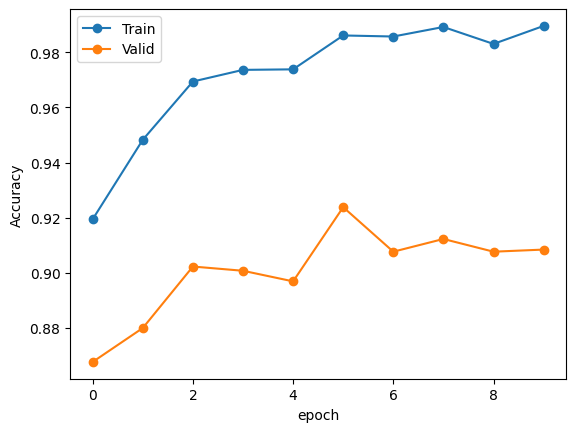

In [22]:
# from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
# # decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
# decision_v_dl = DataLoader(decisionset_v, batch_size=32)
# train_dl=DataLoader(trainset, batch_size=32,sampler=ImbalancedDatasetSampler(trainset))
model_decision=model_train(model_algo,train_dl,valid_dl,"decision",70,model_0=model_0)

In [23]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=False, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=False, batch_size=batch_size)

Epoch=0,train_loss=0.14016036838700474,train_accu=0.959472499195883
Epoch=0,valid_loss=0.4463396978590628,valid_accu=0.8880407124681934
0
Epoch=1,train_loss=0.062336497695984164,train_accu=0.986812479897073
Epoch=1,valid_loss=0.4046699733072868,valid_accu=0.9033078880407125
0
Epoch=2,train_loss=0.02656171466911379,train_accu=0.9942103570279833
Epoch=2,valid_loss=0.39908868954078536,valid_accu=0.9122137404580153
0
Epoch=3,train_loss=0.019576214624753945,train_accu=0.9954969443550981
Epoch=3,valid_loss=0.42068767960896625,valid_accu=0.9033078880407125
Epoch=4,train_loss=0.04436333818812296,train_accu=0.9855258925699582
Epoch=4,valid_loss=0.4693100887135088,valid_accu=0.8969465648854962
Epoch=5,train_loss=0.012795288253536022,train_accu=0.9964618848504342
Epoch=5,valid_loss=0.43553275738205316,valid_accu=0.9173027989821882
0
Epoch=6,train_loss=0.00950581803847489,train_accu=0.9971051785139916
Epoch=6,valid_loss=0.4829509645207541,valid_accu=0.905852417302799
Epoch=7,train_loss=0.023872862

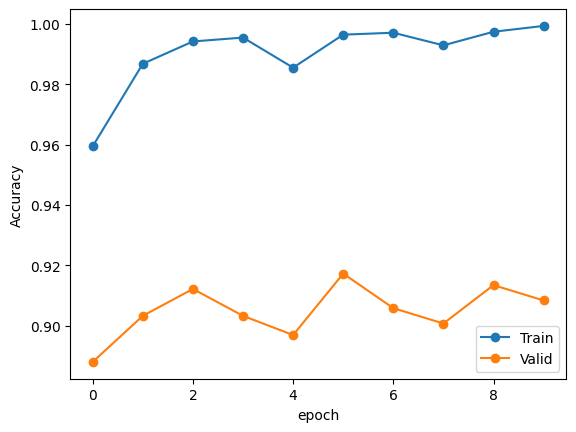

In [24]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.1091205784859468,train_accu=0.9693926351028216
Epoch=0,valid_loss=0.30042476124233664,valid_accu=0.8927875243664717
0
Epoch=1,train_loss=0.043076364197895206,train_accu=0.989478718316595
Epoch=1,valid_loss=0.27271336863147805,valid_accu=0.9220272904483431
0
Epoch=2,train_loss=0.021314219300932906,train_accu=0.9961740793878527
Epoch=2,valid_loss=0.24388565887019859,valid_accu=0.9376218323586745
0
Epoch=3,train_loss=0.01582720717179154,train_accu=0.9947393591582975
Epoch=3,valid_loss=0.2727715664672006,valid_accu=0.9317738791423001
Epoch=4,train_loss=0.012482449089879341,train_accu=0.9976087996174079
Epoch=4,valid_loss=0.3012098430657711,valid_accu=0.9395711500974658
0
Epoch=5,train_loss=0.00562657531714294,train_accu=0.9990435198469632
Epoch=5,valid_loss=0.24334065090378246,valid_accu=0.9395711500974658
Epoch=6,train_loss=0.008233982590690794,train_accu=0.9990435198469632
Epoch=6,valid_loss=0.28234208861754395,valid_accu=0.9376218323586745
Epoch=7,train_loss=0.01012

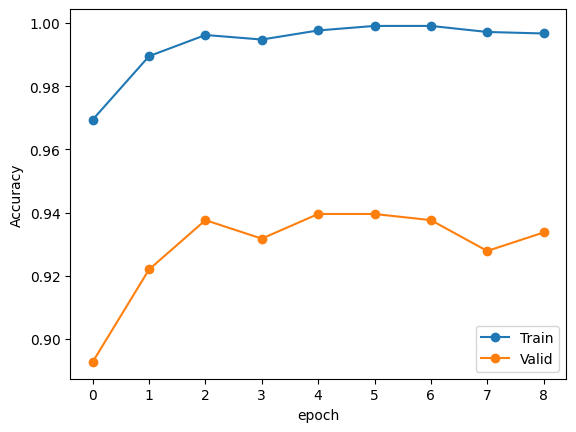

In [25]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [26]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,train_dl,len(trainset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.036978731684100166, 0.9873076923076923)

In [27]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,valid_dl,len(validset),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.21773345503465683, 0.9245573518090839)

In [28]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.010696795584190451, 0.9967835316822129)

In [29]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.009769952641629682, 0.9980870396939263)

In [30]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.4239036792713874, 0.910941475826972)

In [31]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.28323669008343927, 0.9434697855750487)

In [32]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.012631853557048508, 0.9971153846153846, 2091)

In [33]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.38053664067233867, 0.9214780600461894, 513)

In [34]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.23356470152270048, 0.9859615384615384, 2052, 3148)

In [35]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.577725725140913, 0.8668206312548113, 475, 824)

In [36]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [37]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'splitmode={split_mode}')
df

splitmode=('classaccu', [71, 38, 31, 26, 55, 8, 50, 64, 68, 22, 2, 66, 58, 15, 65, 3, 14, 16, 24, 33, 37, 45, 51, 52, 53, 54, 74, 40, 25, 0])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.254095,0.926346,0.608482,0.836798
1,Model_Decision,0.036979,0.987308,0.217733,0.924557
2,Model_T,0.010697,0.996784,0.423904,0.910941
3,Model_F,0.009770,0.998087,0.283237,0.943470
4,Total_Model,0.233565,0.985962,1.577726,0.866821
5,Total_Model_with_perfect_decision,0.012632,0.997115,0.380537,0.921478


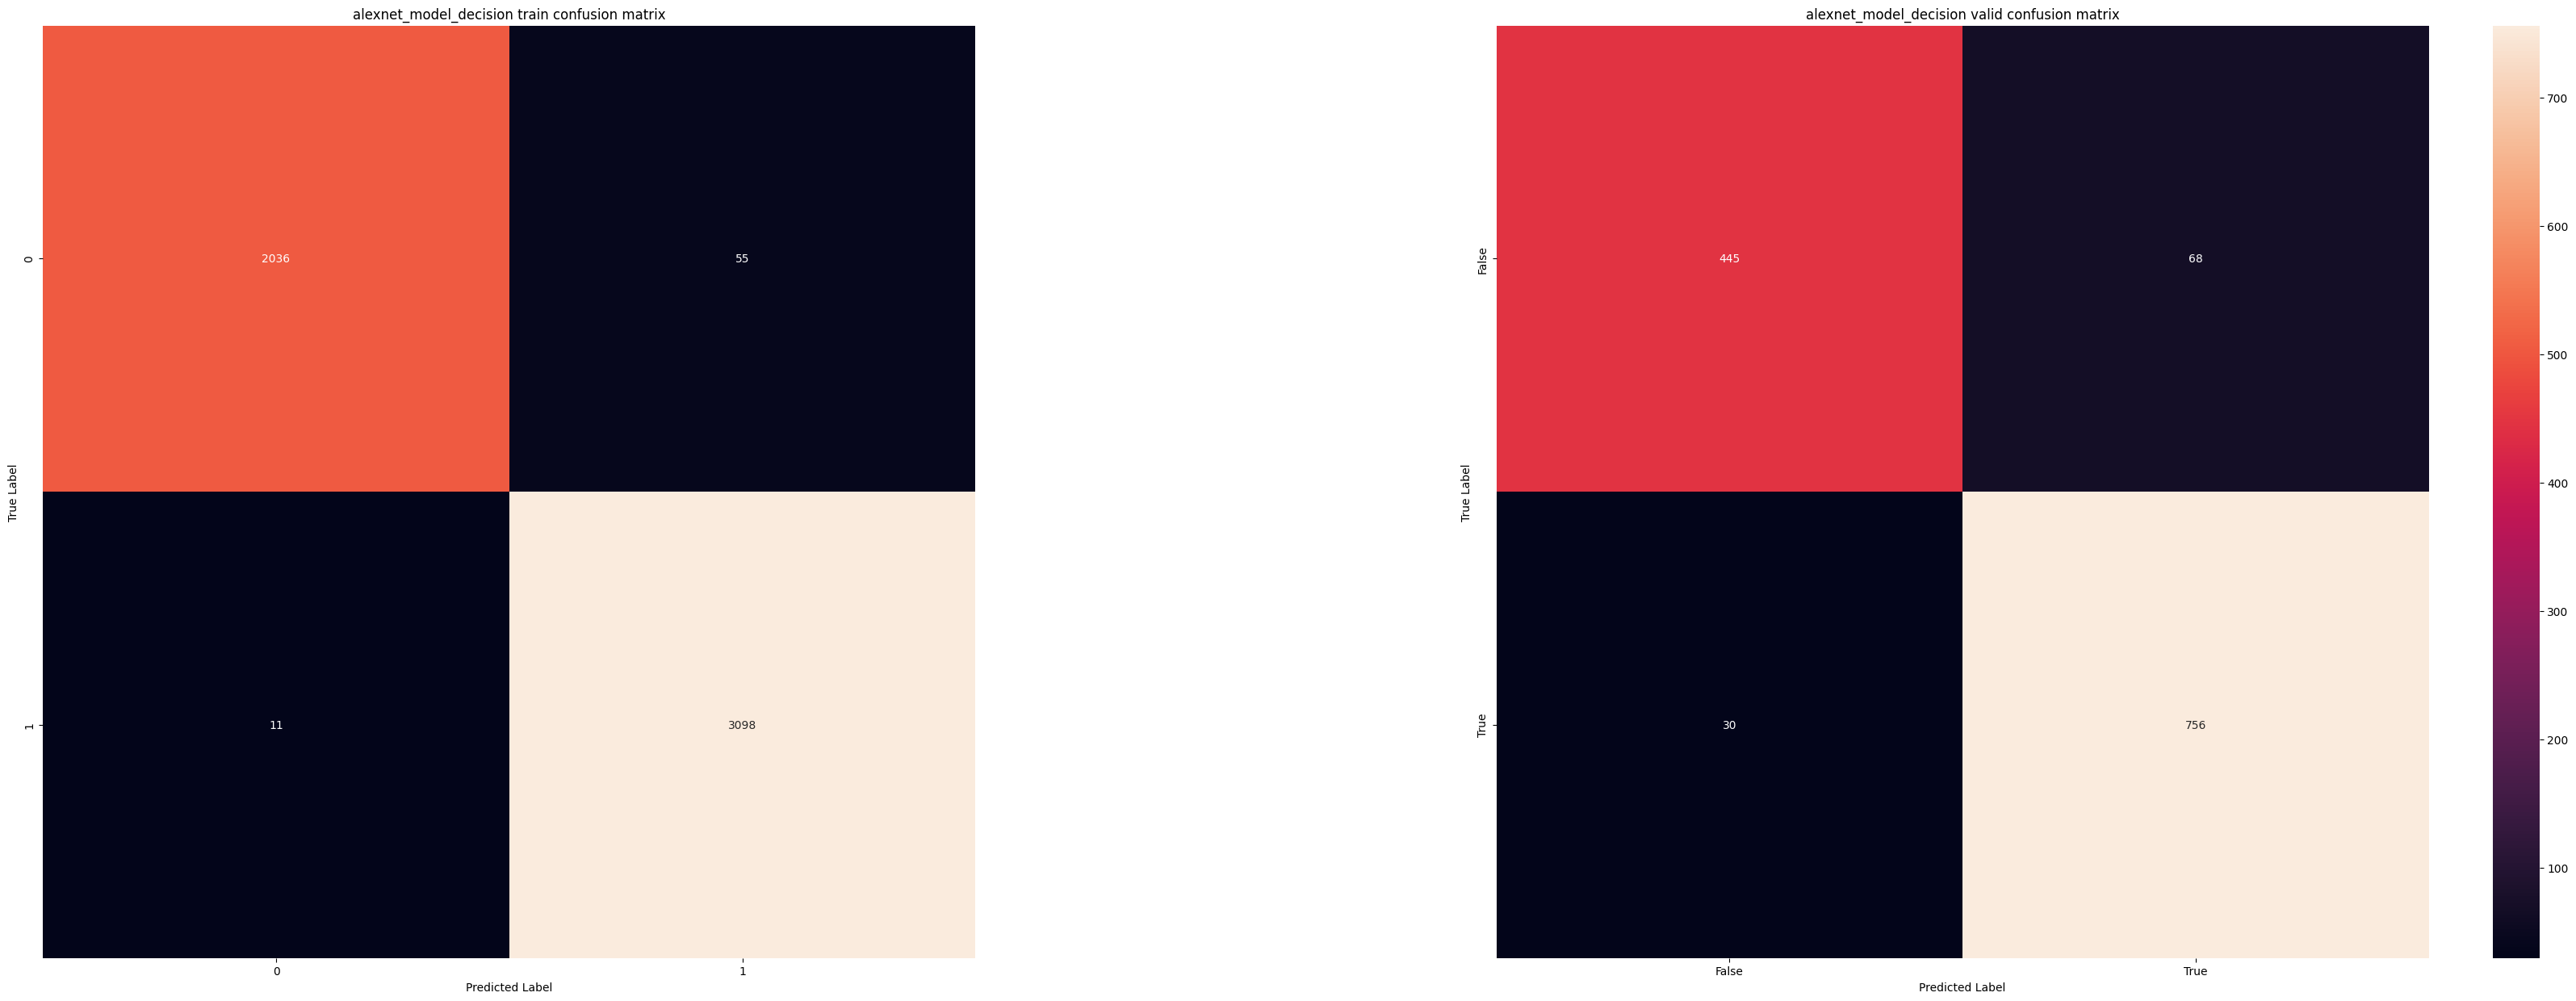

In [38]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

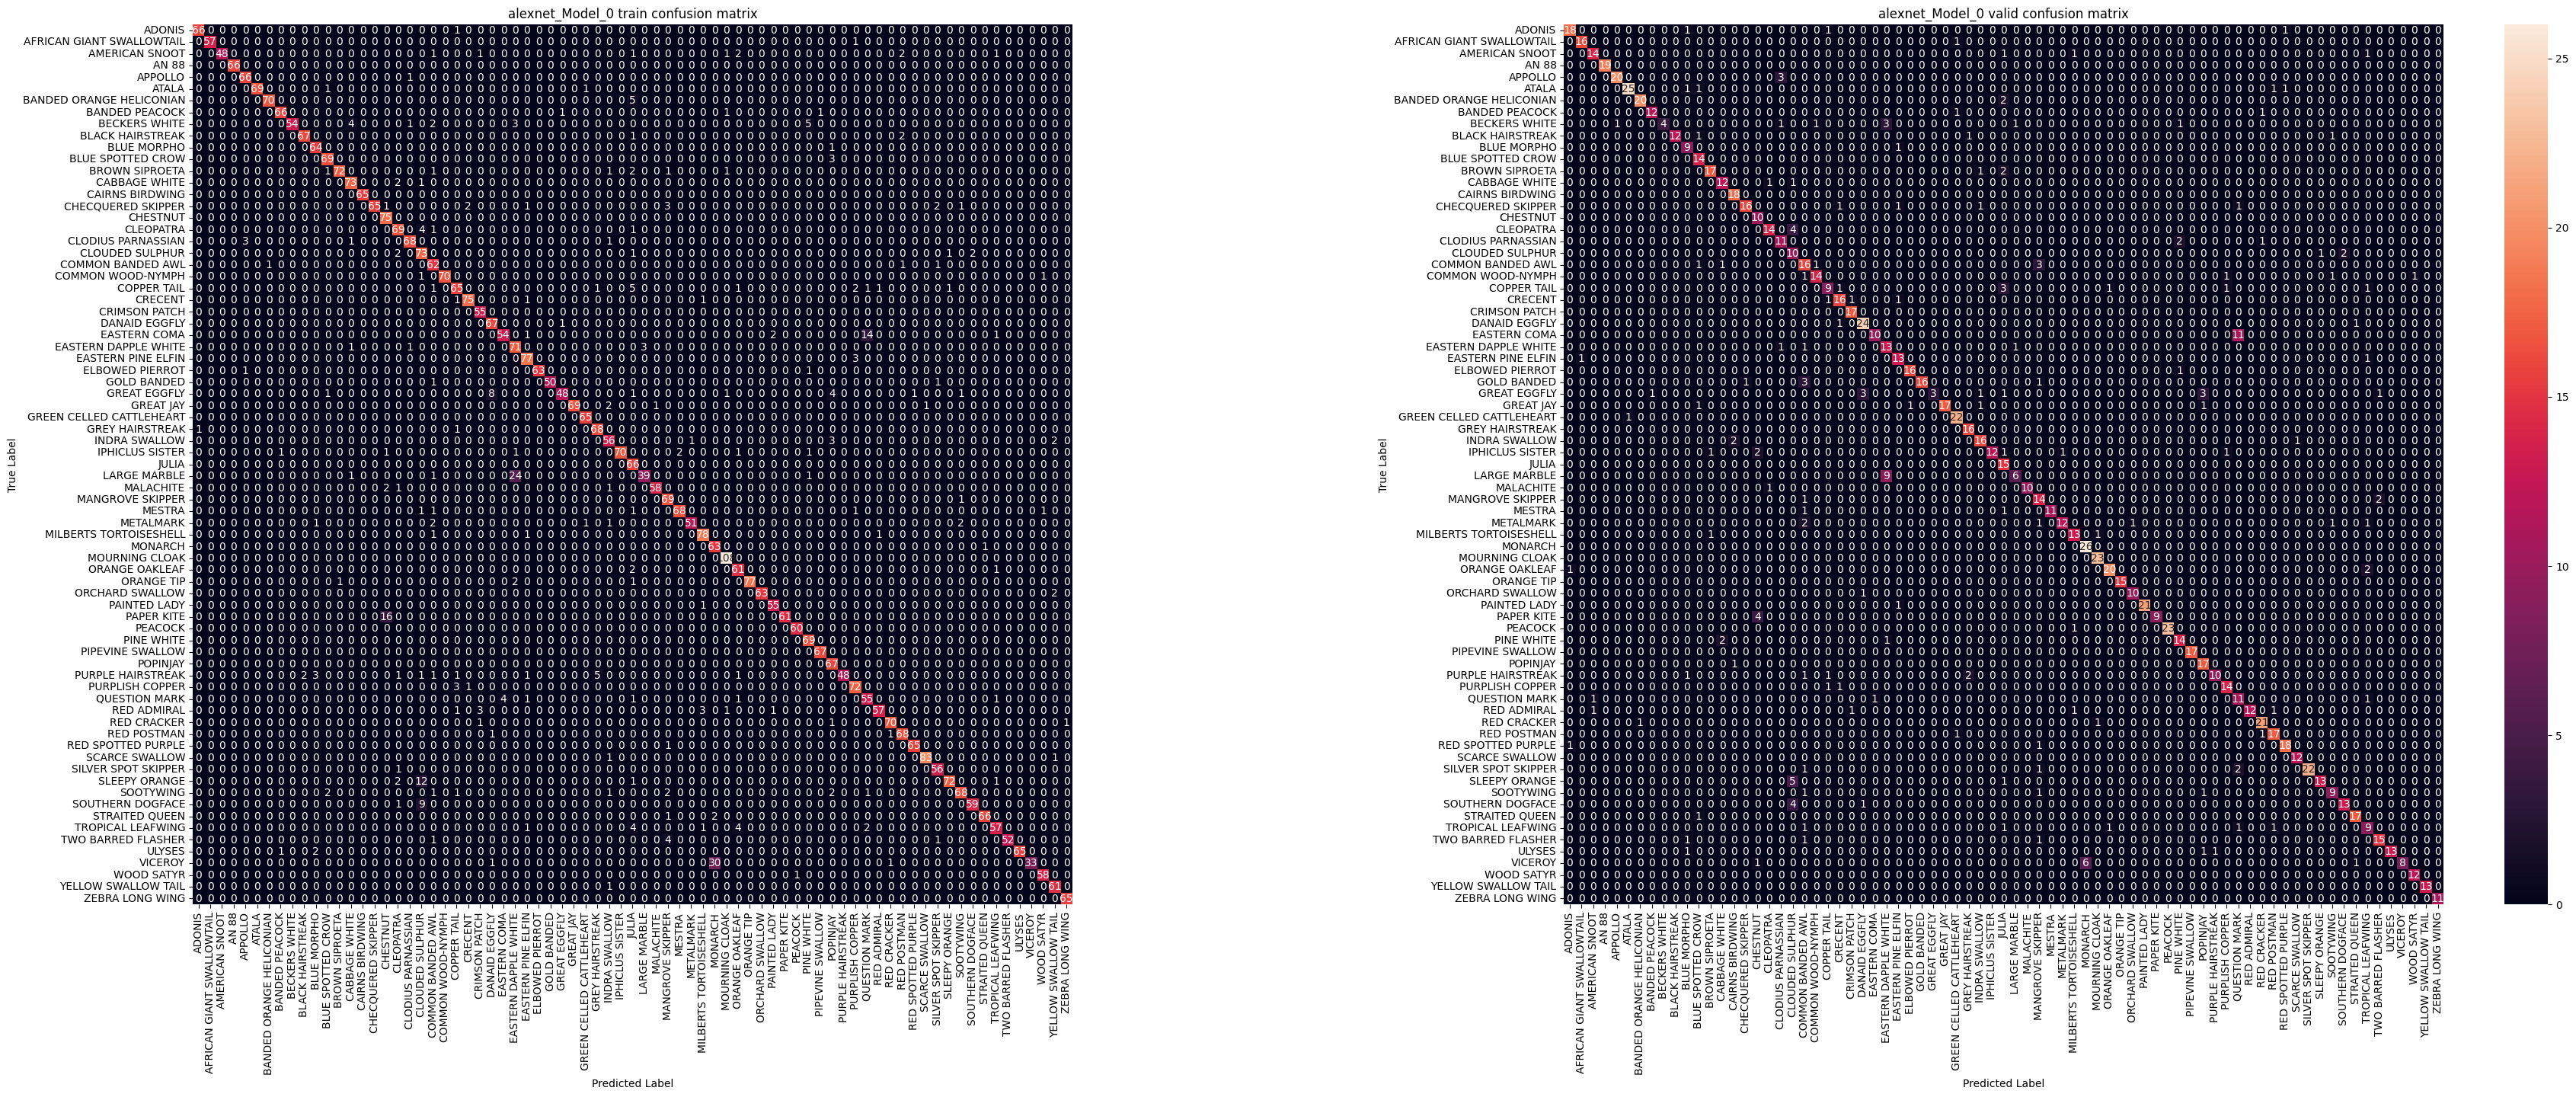

In [39]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

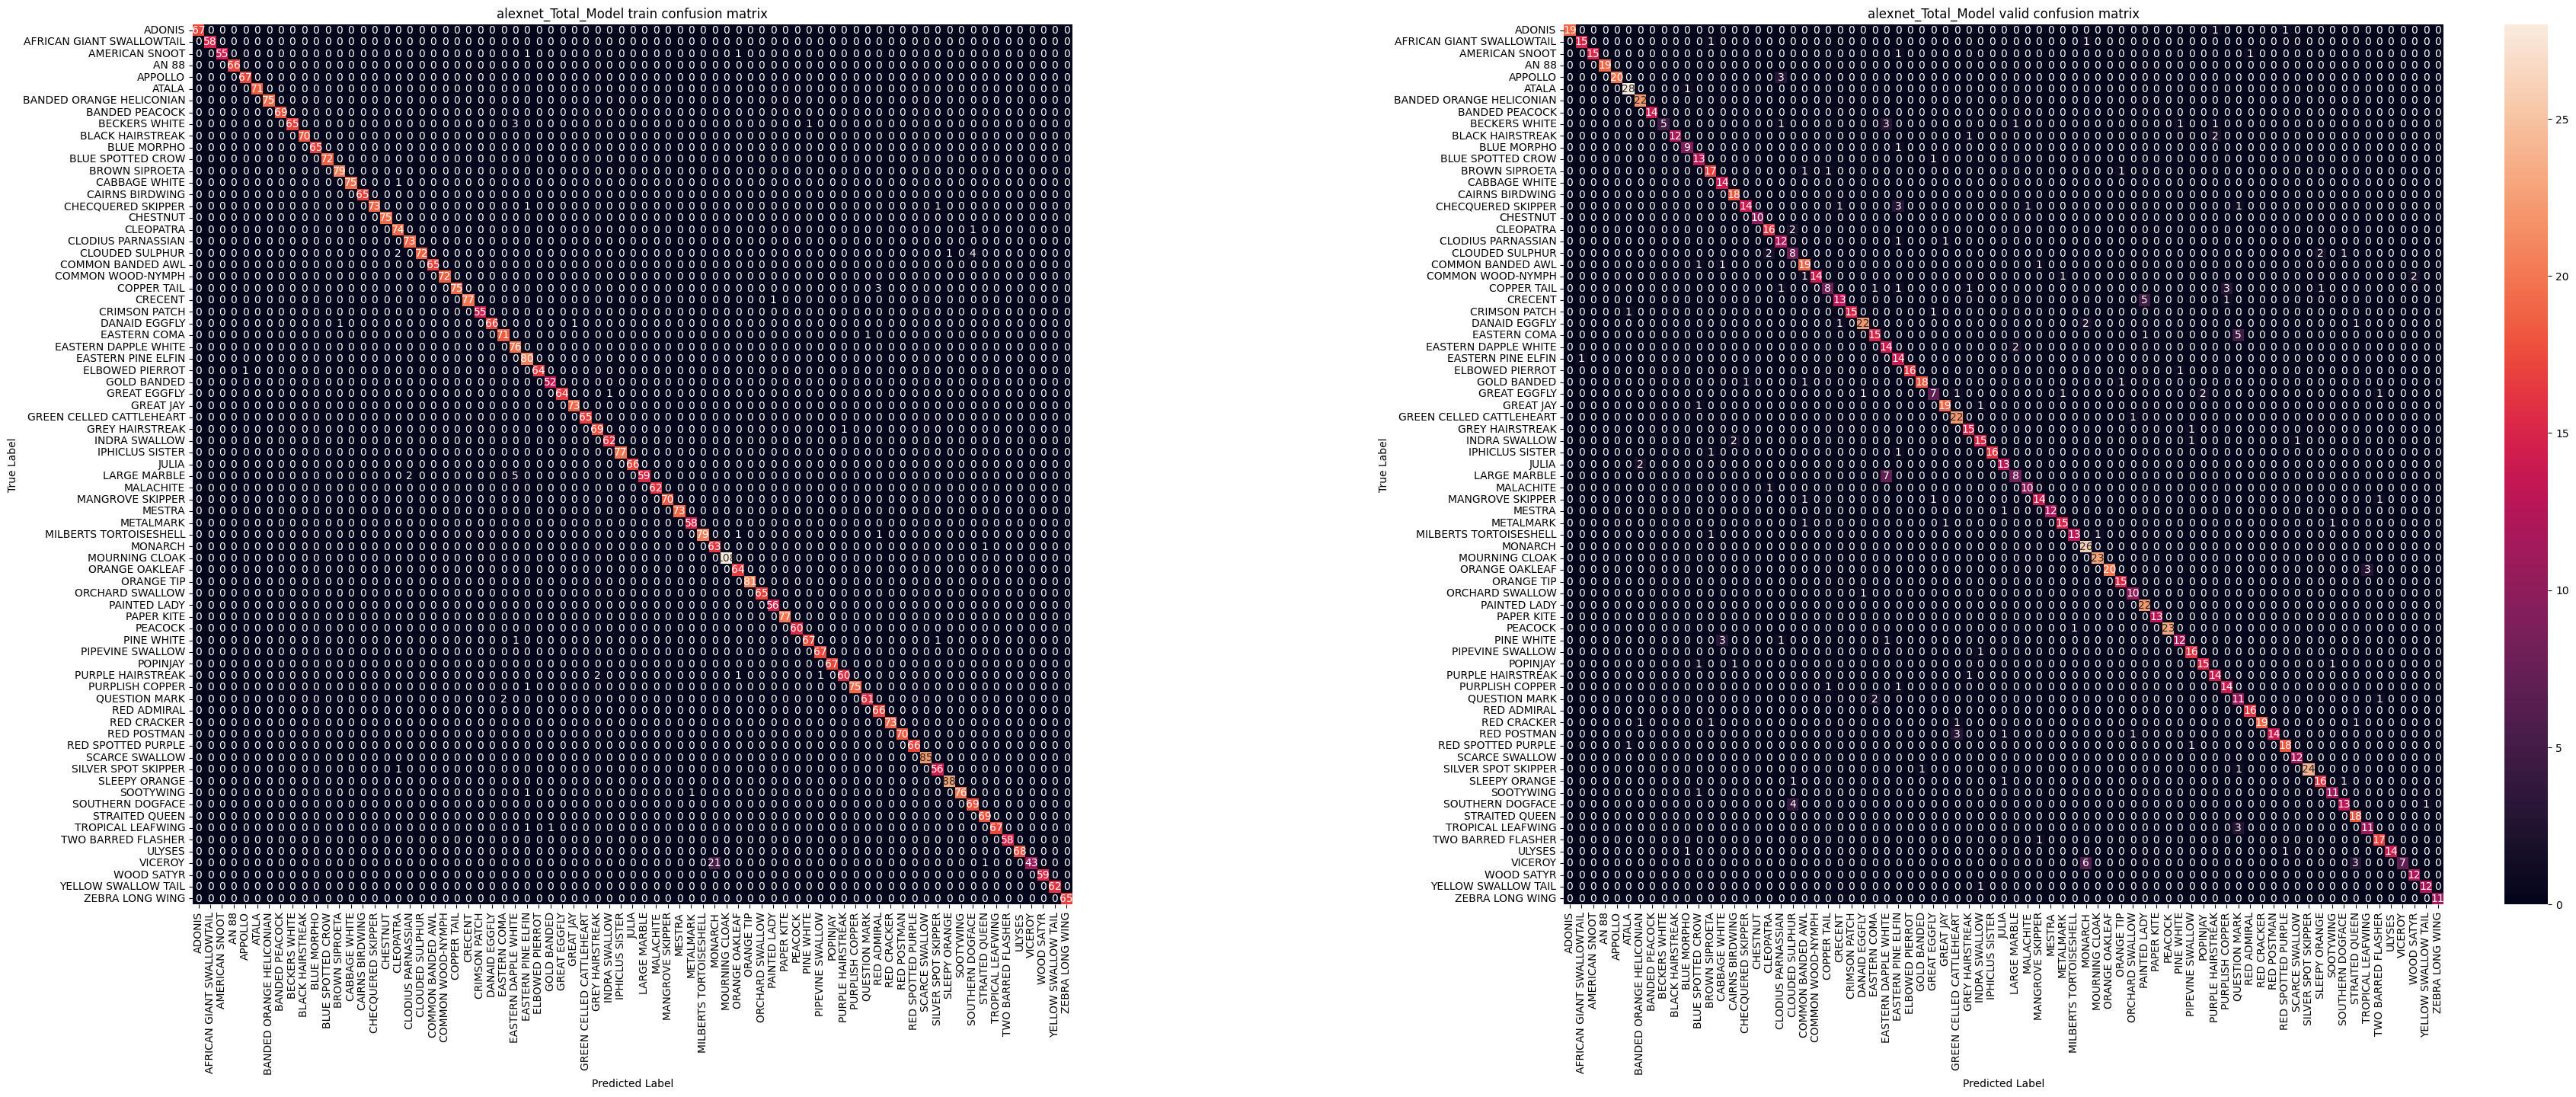

In [40]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

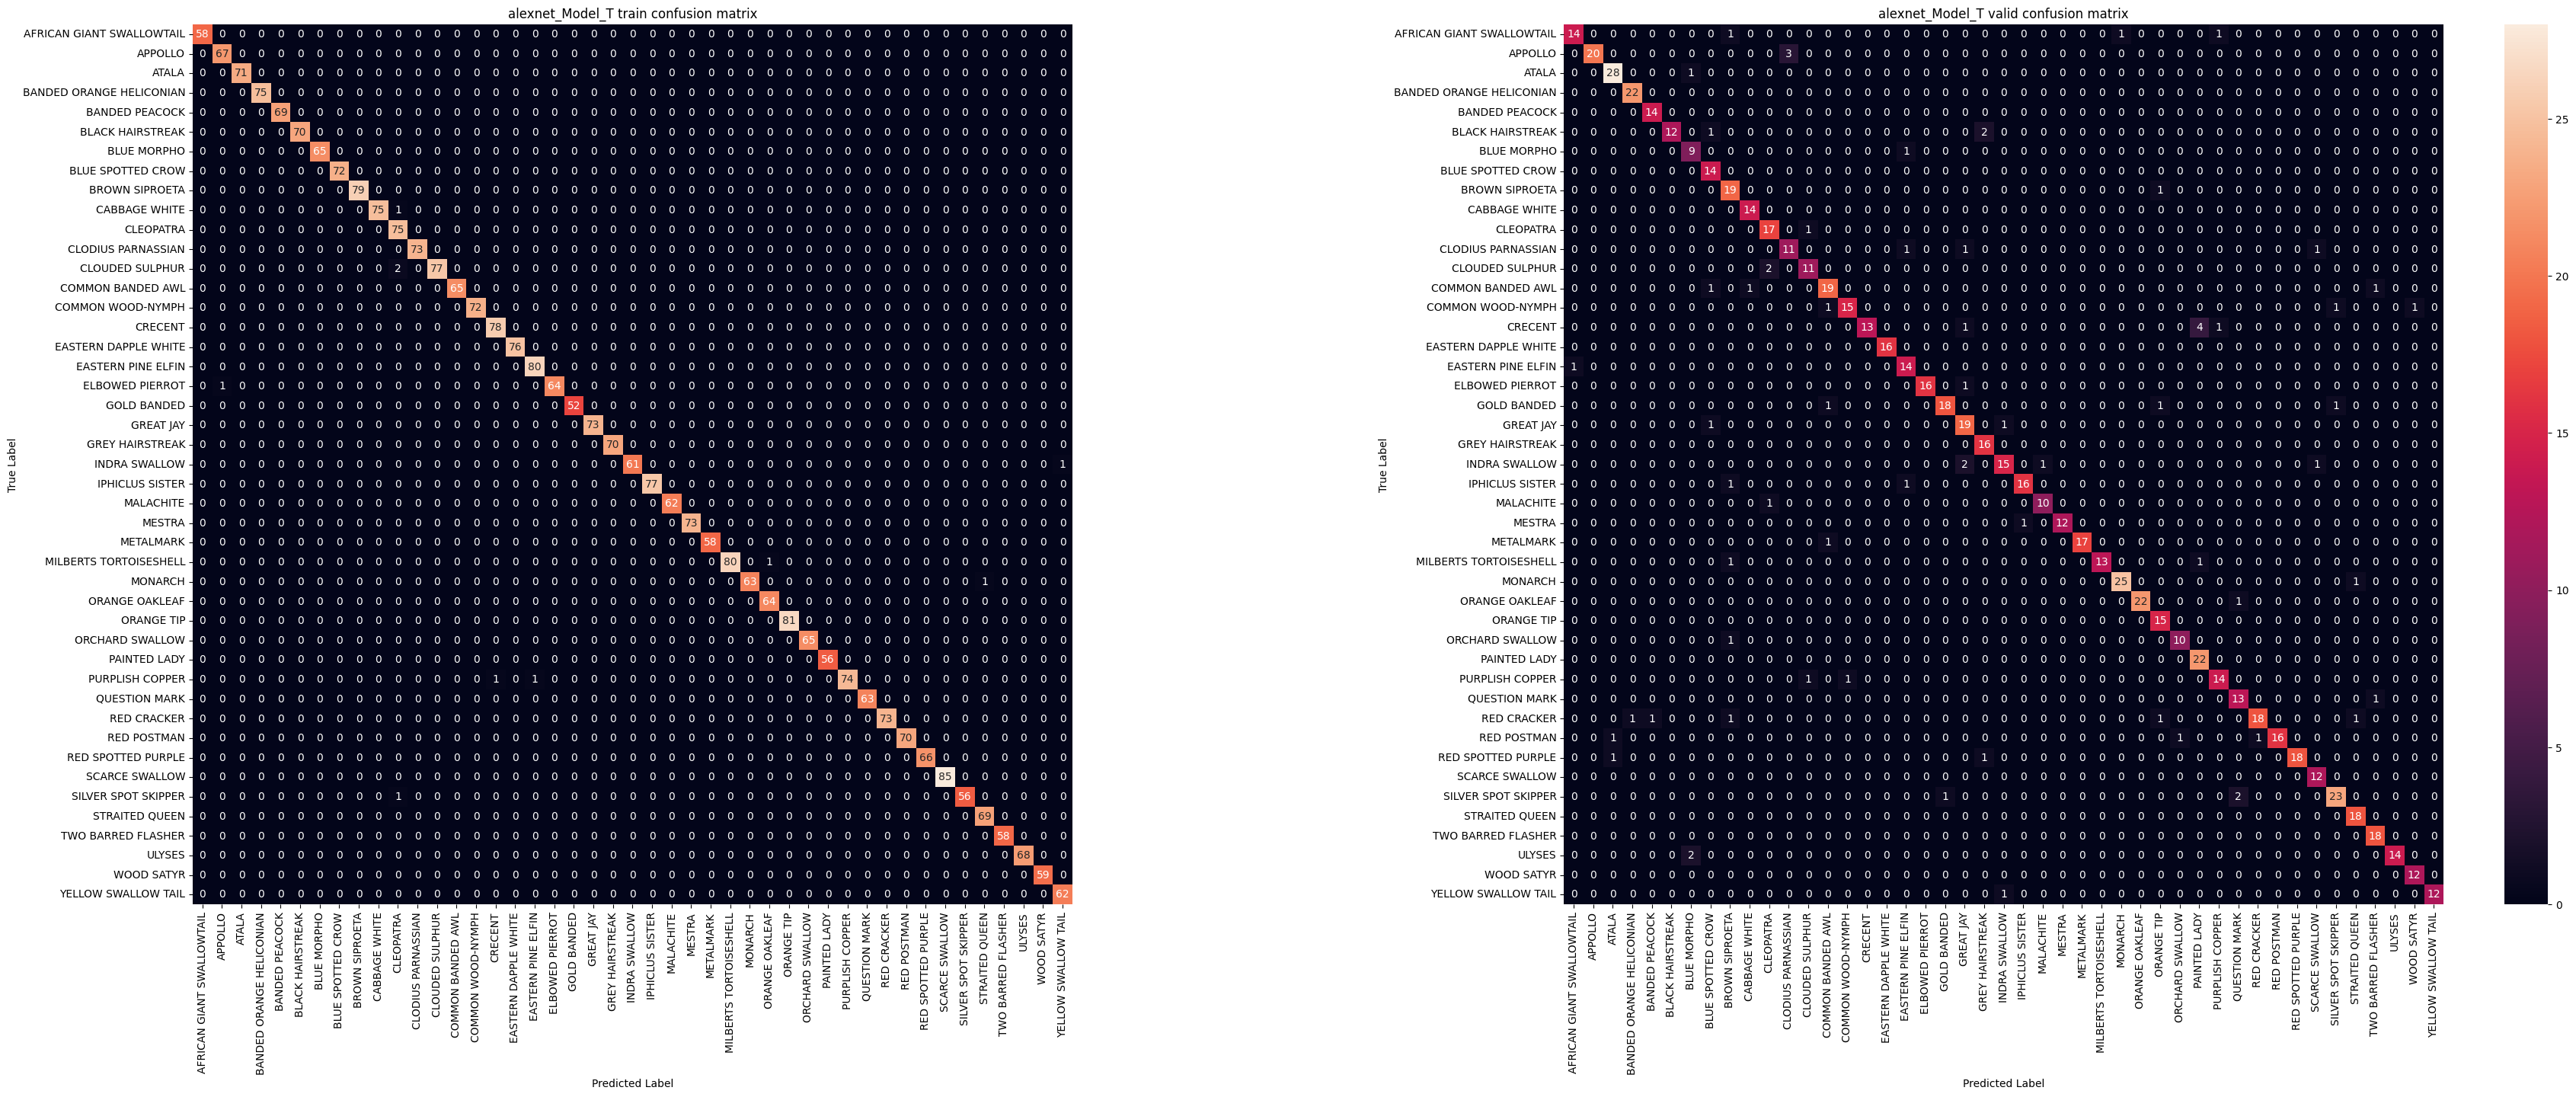

In [41]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

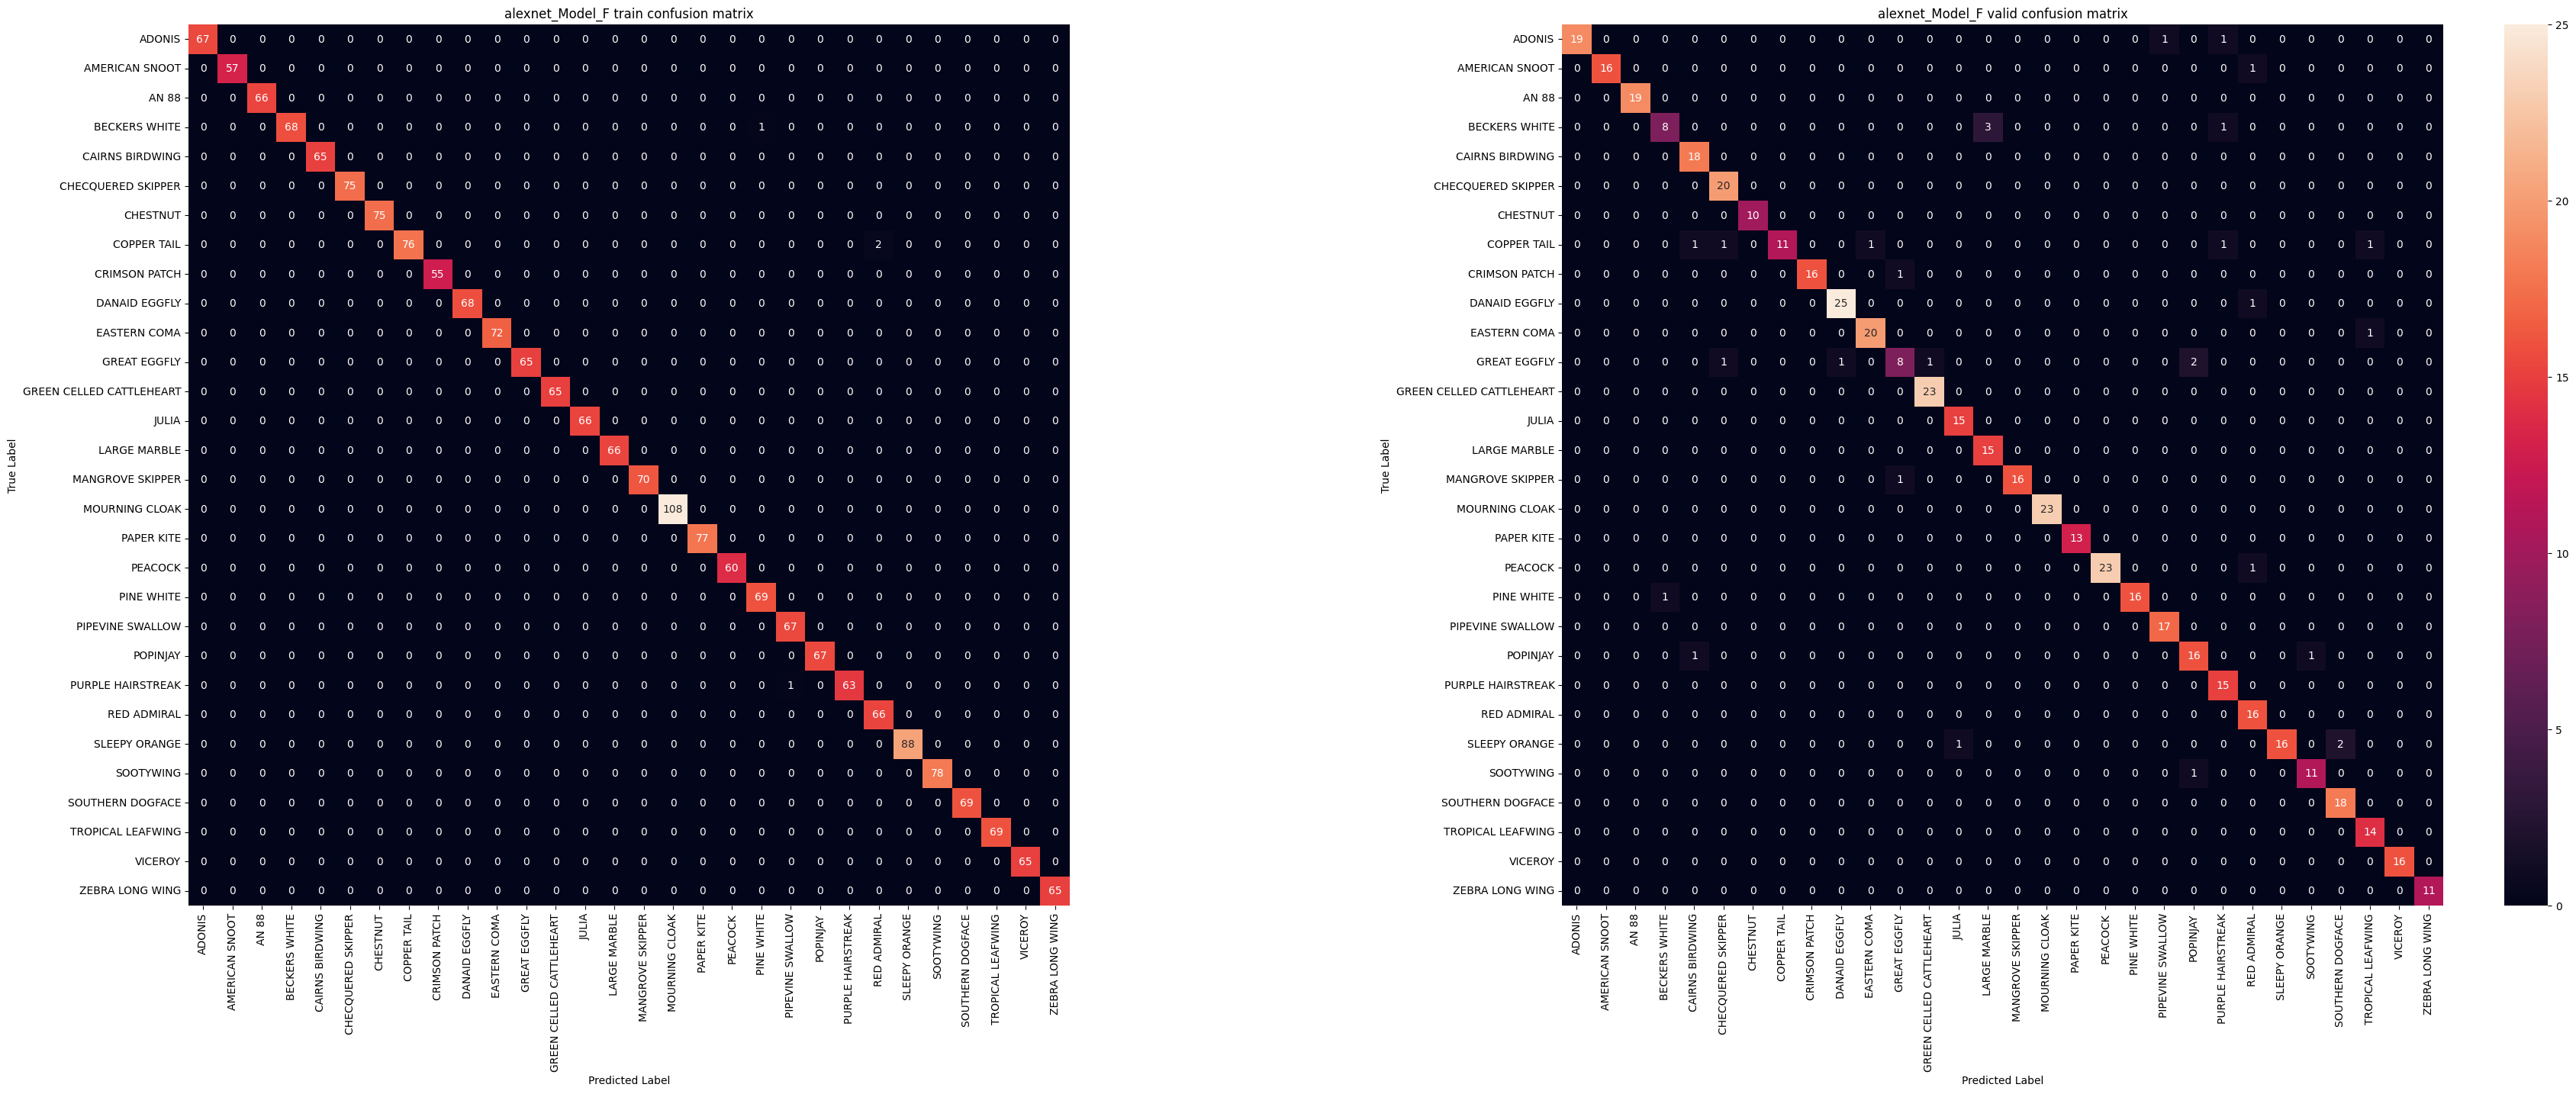

In [42]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [43]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,_,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [44]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,4388,14,14,32,14,0.999109,0.991878,0.976486,0.987380,True,False,True,False,False
1,3693,73,25,73,73,0.480621,0.999808,0.982378,0.999995,False,True,True,True,True
2,2059,19,66,19,19,0.999943,0.999974,0.881583,0.993119,False,True,True,True,True
3,3306,38,38,27,38,0.999997,0.999561,0.673216,0.879320,True,False,True,False,False
4,2685,31,31,61,31,0.999764,0.914670,0.904625,0.999810,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,1871,32,33,32,32,0.393254,0.999984,0.981999,1.000000,False,True,True,True,True
5196,6171,61,58,61,61,0.968717,0.999958,0.989177,0.998319,False,True,True,True,True
5197,3537,1,15,1,1,0.996560,0.999999,0.999951,0.999994,False,True,True,True,True
5198,682,20,68,20,20,0.944894,0.999407,0.988831,0.988032,False,True,True,True,True


In [45]:
len(df_results[df_results['Decision']!=df_results['flag']])

65

In [46]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
21,4199,65,65,42,35,0.905934,0.287546,0.522877,0.948414,True,False,False,True,False
89,848,68,68,30,43,0.988998,0.774770,0.193074,0.527917,True,False,False,True,False
107,3254,71,71,44,44,0.999948,0.999576,0.845009,0.670737,True,False,False,True,False
154,663,8,8,27,8,0.935558,0.860152,0.350694,0.748925,True,False,True,True,False
273,2050,38,38,27,27,0.993573,0.971053,0.545452,0.703353,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4218,4956,71,71,44,71,0.999999,0.999999,0.921614,0.511839,True,False,True,True,False
4303,3064,38,38,18,38,0.842086,0.999606,0.373614,0.901776,True,False,True,True,False
4363,5133,19,64,19,19,0.961596,0.999935,0.899204,0.536499,False,True,True,False,True
4651,362,26,26,57,26,0.999122,0.721300,0.816653,0.502228,True,False,True,True,False


In [47]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

71    23
38     8
8      3
25     3
57     3
65     2
22     2
68     2
15     2
34     2
26     2
19     2
17     2
31     1
55     1
52     1
27     1
54     1
66     1
2      1
43     1
42     1
Name: Target, dtype: int64

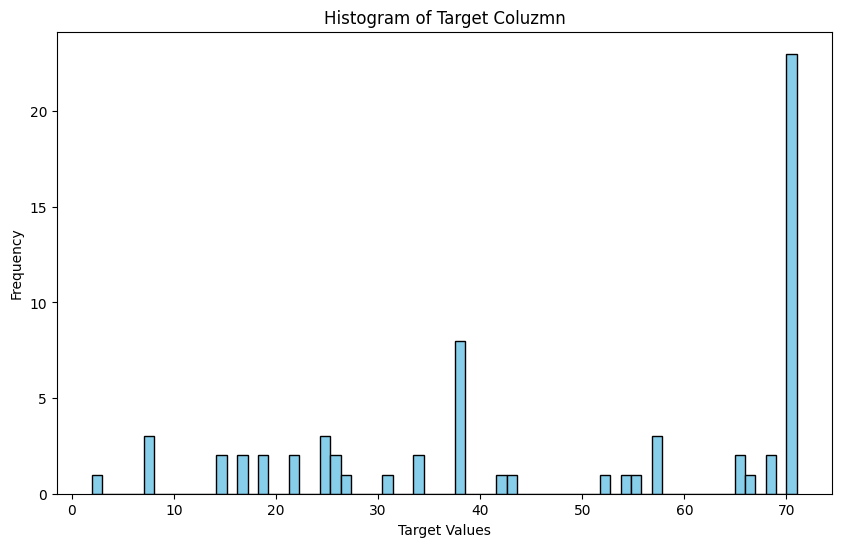

In [48]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [49]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,4576,42,33,42,42,0.862047,0.993354,0.912566,0.999861,False,True,True,True,True
1,3457,51,51,59,51,0.953843,0.502344,0.817902,0.999774,True,False,True,False,False
2,2484,34,55,34,34,0.788231,0.999828,0.827382,0.999965,False,True,True,True,True
3,3737,50,50,59,50,0.999993,0.634796,0.773466,0.999997,True,False,True,False,False
4,6475,51,51,57,51,0.999999,0.773075,0.999455,0.999990,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294,4999,20,55,20,20,0.805956,0.996921,0.969997,0.970172,False,True,True,True,True
1295,1647,55,55,34,34,0.993834,0.999274,0.491710,0.871601,True,False,False,True,False
1296,5495,3,3,32,3,0.999998,0.802198,0.999971,1.000000,True,False,True,False,False
1297,388,39,37,39,39,0.487456,0.762103,0.762051,0.994642,False,True,True,True,True


In [50]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag'])])

95

In [51]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

71    8
38    6
26    6
22    5
52    5
8     5
15    5
60    4
66    4
46    4
25    3
68    3
9     2
27    2
19    2
31    2
40    2
57    2
20    2
37    2
51    1
53    1
54    1
29    1
41    1
48    1
59    1
11    1
34    1
64    1
61    1
30    1
42    1
35    1
16    1
2     1
33    1
65    1
0     1
24    1
55    1
Name: Target, dtype: int64

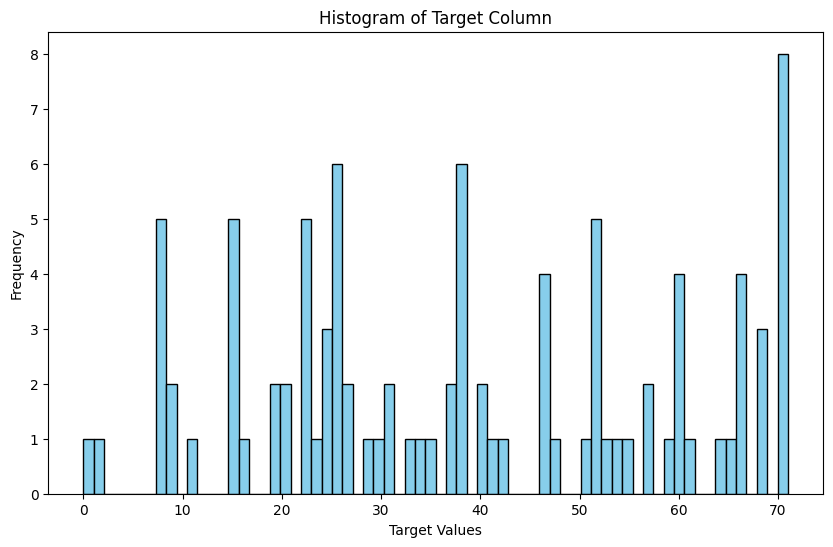

In [52]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()